# DS 4320 Project 1 Pipeline: Credit Card Fraud Detection

## Objective
This notebook loads the relational credit card fraud dataset into DuckDB, prepares a dataset for modeling using SQL, trains a model, and scores how well the model identifies fraud.

In [11]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [12]:
# load the CSV file
transactions = pd.read_csv("../data/sample_transactions.csv")
customers = pd.read_csv("../data/sample_customers.csv")
merchants = pd.read_csv("../data/sample_merchants.csv")
fraud_labels = pd.read_csv("../data/sample_fraud_labels.csv")

print(transactions.shape)
print(customers.shape)
print(merchants.shape)
print(fraud_labels.shape)

(4992, 33)
(997, 1)
(50, 1)
(4992, 2)


## Data Preparation 
The relational dataset is stored in separate CSV files. These files represent transactions, customers, merchants, and fraud labels.

In [13]:
# load into duckdb
con = duckdb.connect()

con.register("transactions_df", transactions)
con.register("customers_df", customers)
con.register("merchants_df", merchants)
con.register("fraud_labels_df", fraud_labels)

con.execute("CREATE OR REPLACE TABLE transactions AS SELECT * FROM transactions_df")
con.execute("CREATE OR REPLACE TABLE customers AS SELECT * FROM customers_df")
con.execute("CREATE OR REPLACE TABLE merchants AS SELECT * FROM merchants_df")
con.execute("CREATE OR REPLACE TABLE fraud_labels AS SELECT * FROM fraud_labels_df")

In [14]:
con.execute("SHOW TABLES").fetchdf()

,name
0,customers
1,customers_df
2,fraud_labels
3,fraud_labels_df
4,merchants
5,merchants_df
6,transactions
7,transactions_df


In [15]:
# query to prepare the solution
model_df = con.execute("""
    SELECT
        t.*,
        f.Class
    FROM transactions t
    JOIN fraud_labels f
        ON t.transaction_id = f.transaction_id
""").fetchdf()

model_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,transaction_id,customer_id,merchant_id,Class
0,161085.0,1.983253,-0.176808,-0.234645,0.420610,-0.524881,-0.517922,-0.426280,-0.085440,1.058515,...,1.133433,-0.414366,-0.684325,0.039992,-0.018518,0.12,263729,729,29,0
1,144921.0,-0.668908,1.401700,-0.105966,-0.697902,0.250835,-1.096017,0.845909,0.014705,0.223832,...,-0.011753,-0.381611,0.124993,0.179492,-0.068217,1.98,227066,66,16,0
2,130476.0,-0.631970,1.749792,-0.057029,0.957674,1.566792,-0.287978,1.778291,-0.349138,-1.306805,...,0.540801,1.189802,-0.228100,-0.049005,0.082245,46.03,194199,199,49,0
3,142929.0,-2.130823,0.266709,0.297901,-0.666425,-0.767904,-0.341857,-0.258019,1.031254,0.299701,...,0.756948,-0.062582,0.646321,0.214136,-0.019755,116.10,222324,324,24,0
4,57976.0,0.947075,-0.402152,1.150211,0.531900,-0.197880,2.060615,-1.035872,0.797776,0.600676,...,-0.973012,-0.079638,0.426819,0.086370,0.003452,11.50,79342,342,42,0


## Query Preparation
The transaction and fraud label tables were joined to create the final modeling dataset. This query reconstructs the outcome variable needed for supervised fraud detection.

In [16]:
# define features and target
X = model_df.drop(columns=["transaction_id", "customer_id", "merchant_id", "Class"])
y = model_df["Class"]

print(X.shape)
print(y.value_counts())

(4992, 30)
Class
0    4500
1     492
Name: count, dtype: int64


In [17]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [18]:
#implement a model
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [19]:
# evaluate results
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9872    0.9741    0.9806      1350
           1     0.7892    0.8851    0.8344       148

    accuracy                         0.9653      1498
   macro avg     0.8882    0.9296    0.9075      1498
weighted avg     0.9677    0.9653    0.9662      1498



In [20]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1315,   35],
       [  17,  131]])

## Analysis Rationale
This model has good fraud detection capabilities. The recall score for the fraud class is 0.885, meaning we catch about 88.5% of all fraud. We care about this metric because we don't want to miss any fraud cases.

The precision score is lower at 0.789 for fraud. This means that while we do predict some transactions as fraud that do not turn out to be fraud, most of the transactions we flag are truly fraud. We are usually ok with this tradeoff when it comes to fraud detection. It is better to throw up a flag on a suspicious transaction than to miss the fraud entirely.

We can conclude that we can use transaction-level features to predict whether or not a transaction is high-risk for fraud. We still deal with some class imbalance. 

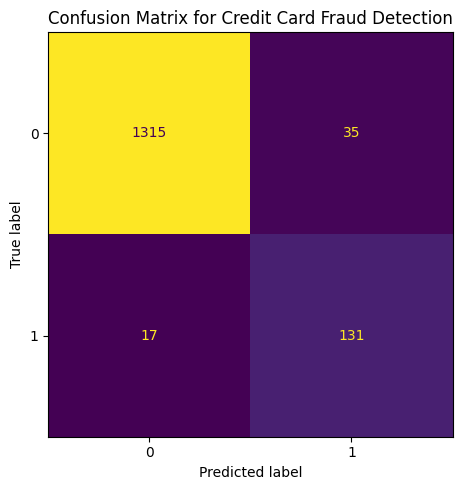

In [21]:
#visualization
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix for Credit Card Fraud Detection")
plt.tight_layout()
plt.show()

## Visualization Rationale
I used a confusion matrix to evaluate model performance because the data is very skewed. The confusion matrix allows you to see how many fraudulent transactions were caught vs how many were missed.

## Final Interpretation
This pipeline addresses the project question by loading transaction data saved in relational tables into DuckDB, using SQL to prepare a dataset fit for modeling, training a classifier, and scoring its ability to detect fraudulent transactions. Fraudulent transactions can be detected using transaction-level features, but class imbalance is still an issue. The model prioritizes recall for fraud detection, which is desirable in financial applications where missing fraudulent transactions is more costly than flagging legitimate ones.